In [26]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
%matplotlib inline
import seaborn as sb

In [27]:
uploaded = files.upload()

Saving crisismanagement1.xlsx to crisismanagement1 (2).xlsx


In [28]:
file_name = 'crisismanagement1.xlsx'

df = pd.read_excel(file_name)

print(df)

   ID_ScenarioC                    CrisisName  CrisisType StartingTimeC  \
0            C1          Flooding in Toulouse       Flood    2021-09-15   
1           C10      Chemical Plant Explosion   Explosion    2001-09-21   
2           C11   Severe Flooding in Toulouse       Flood    2024-06-10   
3           C12  Landslide in Pech-David Hill   Landslide    2023-06-11   
4            C2          Heatwave in Toulouse    Heatwave    2022-07-15   
5            C4                Toulouse Flood       Flood    2018-01-22   
6            C5                Toulouse Flood       Flood    2016-06-13   
7            C6            Toulouse Landslide   Landslide    2019-04-12   
8            C7           Pyrenees Earthquake  Earthquake    2013-04-02   
9            C8           Pyrenees Earthquake  Earthquake    2011-07-21   
10           C9                  Storm Gloria       Storm    2020-01-20   

   EndingTimeC                            AreaC CityNameC CountryNameC  \
0   2021-09-17           

In [29]:
import pandas as pd

# Load the Excel file
file_name = 'crisismanagement1.xlsx'
excel_data = pd.ExcelFile(file_name)

# Print all sheet names to ensure they are correctly identified
print(excel_data.sheet_names)

# Load each sheet into a DataFrame using the exact sheet names
crisisscenario_df = pd.read_excel(file_name, sheet_name='crisisscenario')
activity_df = pd.read_excel(file_name, sheet_name='activity')
realactivity_df = pd.read_excel(file_name, sheet_name='realactivity')
actor_df = pd.read_excel(file_name, sheet_name='actor')
include_df = pd.read_excel(file_name, sheet_name='include')
apply_df = pd.read_excel(file_name, sheet_name='apply')
chasplan_df = pd.read_excel(file_name, sheet_name='chasplan')
component_df = pd.read_excel(file_name, sheet_name='component')
composition_df = pd.read_excel(file_name, sheet_name='composition')
dependence_df = pd.read_excel(file_name, sheet_name='dependence')
do_df = pd.read_excel(file_name, sheet_name='do')
feedback_df = pd.read_excel(file_name, sheet_name='feedback')
impacting_df = pd.read_excel(file_name, sheet_name='impacting')
generate_df = pd.read_excel(file_name, sheet_name='generate')
hascompo_df = pd.read_excel(file_name, sheet_name='hascompo')
occuring_df = pd.read_excel(file_name, sheet_name='occuring')
perform_df = pd.read_excel(file_name, sheet_name='perform')
plantype_df = pd.read_excel(file_name, sheet_name='plantype')
present_df = pd.read_excel(file_name, sheet_name='present')
risk_df = pd.read_excel(file_name, sheet_name='risk')
risqdammages_df = pd.read_excel(file_name, sheet_name='risqdammages')
stake_df = pd.read_excel(file_name, sheet_name='stake')
useactivity_df = pd.read_excel(file_name, sheet_name='useactivity')

# Display the first few rows of each DataFrame to understand the structure
print(crisisscenario_df.head())
print(activity_df.head())
print(realactivity_df.head())
print(actor_df.head())
print(include_df.head())
print(apply_df.head())
print(chasplan_df.head())
print(component_df.head())
print(composition_df.head())
print(dependence_df.head())
print(do_df.head())
print(feedback_df.head())
print(impacting_df.head())
print(generate_df.head())
print(hascompo_df.head())
print(occuring_df.head())
print(perform_df.head())
print(plantype_df.head())
print(present_df.head())
print(risk_df.head())
print(risqdammages_df.head())
print(stake_df.head())
print(useactivity_df.head())


['crisisscenario', 'activity', 'realactivity', 'actor', 'include', 'apply', 'chasplan', 'component', 'composition', 'dependence', 'do', 'feedback', 'impacting', 'generate', 'hascompo', 'occuring', 'perform', 'plantype', 'present', 'risk', 'risqdammages', 'stake', 'useactivity']
  ID_ScenarioC                    CrisisName CrisisType StartingTimeC  \
0           C1          Flooding in Toulouse      Flood    2021-09-15   
1          C10      Chemical Plant Explosion  Explosion    2001-09-21   
2          C11   Severe Flooding in Toulouse      Flood    2024-06-10   
3          C12  Landslide in Pech-David Hill  Landslide    2023-06-11   
4           C2          Heatwave in Toulouse   Heatwave    2022-07-15   

  EndingTimeC                    AreaC CityNameC CountryNameC  ImageC  \
0  2021-09-17       Garonne River Area  Toulouse       France     NaN   
1  2001-09-21  AZF Chemical Plant Area  Toulouse       France     NaN   
2         NaT       Garonne River Area  Toulouse       France  

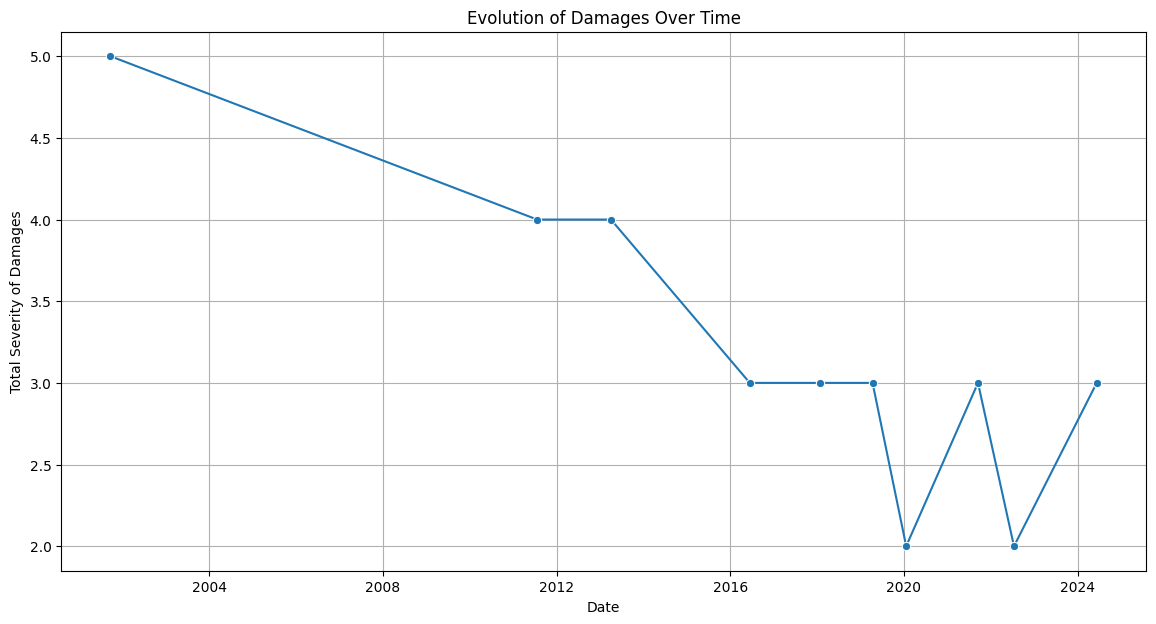

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge the necessary data
merged_df = pd.merge(occuring_df, risqdammages_df, on='Id_RD')
merged_df['DateOccuringRC'] = pd.to_datetime(merged_df['DateOccuringRC'])

# Map severity to numerical values
severity_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4, 'Critical': 5}
merged_df['SeverityRD'] = merged_df['SeverityRD'].map(severity_mapping)

# Aggregate data by date
time_series_df = merged_df.groupby('DateOccuringRC')['SeverityRD'].sum().reset_index()

# Plotting the data
plt.figure(figsize=(14, 7))
sns.lineplot(data=time_series_df, x='DateOccuringRC', y='SeverityRD', marker='o')
plt.title('Evolution of Damages Over Time')
plt.xlabel('Date')
plt.ylabel('Total Severity of Damages')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the Excel file
file_name = 'crisismanagement1.xlsx'
excel_data = pd.ExcelFile(file_name)

# Load necessary sheets into DataFrames
risk_df = pd.read_excel(file_name, sheet_name='risk')

# Define the severity mapping
severity_mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4, 'Critical': 5}

# Apply the severity mapping
risk_df['SeverityR'] = risk_df['SeverityR'].map(severity_mapping)

# Check for any unmapped values (those that resulted in NaN)
unmapped_values = risk_df[risk_df['SeverityR'].isna()]
if not unmapped_values.empty:
    print("Unmapped values found in SeverityR:")
    print(unmapped_values)
else:
    print("All SeverityR values mapped correctly.")

# Remove or handle unmapped values
risk_df = risk_df.dropna(subset=['SeverityR'])


All SeverityR values mapped correctly.


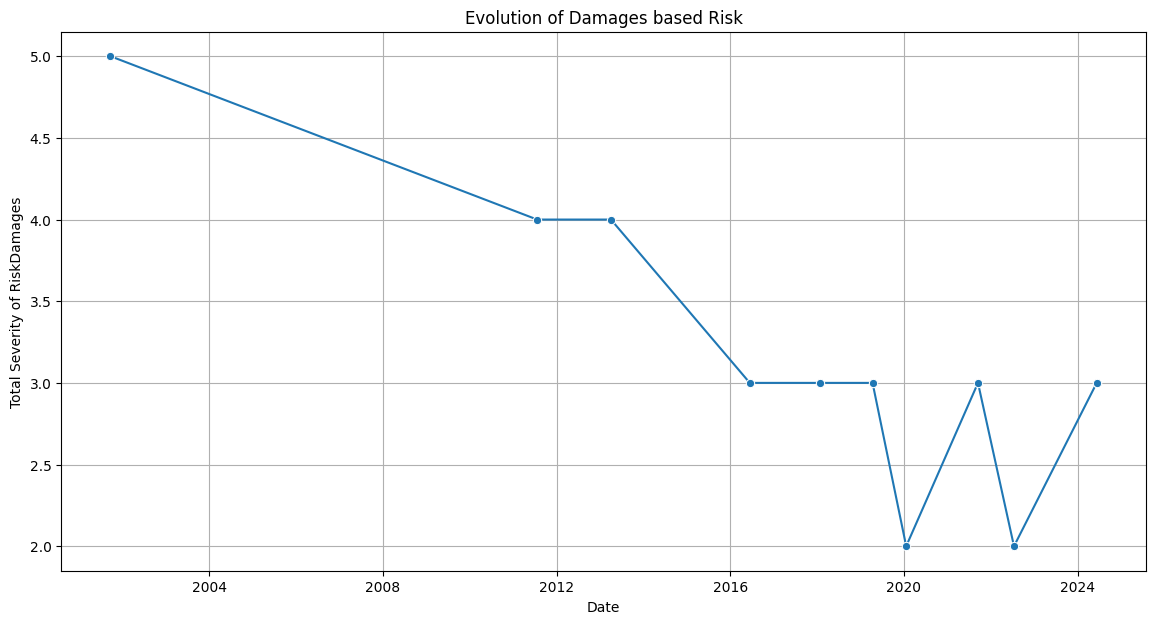

In [32]:
# Question 2

import seaborn as sns  # Import seaborn library
import pandas as pd
import matplotlib.pyplot as plt  # Other libraries you might already have



# Calculate damage severity by date
time_series_df = merged_df.groupby('DateOccuringRC')['SeverityRD'].sum().reset_index()

# Plotting the time series data
plt.figure(figsize=(14, 7))
sns.lineplot(data=time_series_df, x='DateOccuringRC', y='SeverityRD', marker='o')
plt.title('Evolution of Damages based Risk')
plt.xlabel('Date')
plt.ylabel('Total Severity of RiskDamages')
plt.grid(True)
plt.show()


In [21]:
# Frequent risks
risk_counts = risk_df.groupby('TypeRisk').size().to_frame(name='Count').reset_index()
top_frequent_risks = risk_counts.sort_values(by='Count', ascending=False).head(3)

# Severe risks
most_severe_risks = risk_df.sort_values(by='SeverityR', ascending=False).head(3)

print("Top 3 Most Frequent Risks:")
print(top_frequent_risks)
print("Top 3 Most Severe Risks:")
print(most_severe_risks)



Top 3 Most Frequent Risks:
         TypeRisk  Count
0  Chemical Spill      1
1    Cyber Attack      1
2         Drought      1
Top 3 Most Severe Risks:
  IdRisk        TypeRisk  SeverityR                       MitigationStrategy  \
7     R4      Earthquake  Very High                         Emergency Drills   
2    R11  Chemical Spill     Medium  Containment Protocols and Cleanup Teams   
5     R2        Heatwave     Medium                          Cooling Centers   

  ProbabilityR  ImpactArea                LocationR  LatitudeR    LongitudeR  
7          Low       Urban            Saint-Cyprien       1.4359     43.6022  
2          Low  Industrial               Borderouge       1.4550     43.6351  
5       Medium   City-wide  EHPAD Les Jardins d'Oly       1.4484     43.5790  


In [22]:
# Print results as tables (avoiding index numbers)
print("Top 3 Most Frequent Risks:")
print(top_frequent_risks.to_string(index=False))  # Avoids printing index numbers

print("\nTop 3 Most Severe Risks:")
print(most_severe_risks.to_string(index=False))


Top 3 Most Frequent Risks:
      TypeRisk  Count
Chemical Spill      1
  Cyber Attack      1
       Drought      1

Top 3 Most Severe Risks:
IdRisk       TypeRisk SeverityR                      MitigationStrategy ProbabilityR ImpactArea               LocationR  LatitudeR    LongitudeR
    R4     Earthquake Very High                        Emergency Drills          Low      Urban           Saint-Cyprien       1.4359     43.6022
   R11 Chemical Spill    Medium Containment Protocols and Cleanup Teams          Low Industrial              Borderouge       1.4550     43.6351
    R2       Heatwave    Medium                         Cooling Centers       Medium  City-wide EHPAD Les Jardins d'Oly       1.4484     43.5790


In [23]:
from tabulate import tabulate

# Print results as tables
print("Top 3 Most Frequent Risks:")
print(tabulate(top_frequent_risks, headers=top_frequent_risks.columns, tablefmt="grid"))

print("\nTop 3 Most Severe Risks:")
print(tabulate(most_severe_risks, headers=most_severe_risks.columns, tablefmt="grid"))


Top 3 Most Frequent Risks:
+----+----------------+---------+
|    | TypeRisk       |   Count |
+====+================+=========+
|  0 | Chemical Spill |       1 |
+----+----------------+---------+
|  1 | Cyber Attack   |       1 |
+----+----------------+---------+
|  2 | Drought        |       1 |
+----+----------------+---------+

Top 3 Most Severe Risks:
+----+----------+----------------+-------------+-----------------------------------------+----------------+--------------+-------------------------+---------------+--------------+
|    | IdRisk   | TypeRisk       | SeverityR   | MitigationStrategy                      | ProbabilityR   | ImpactArea   | LocationR               |   LatitudeR   |   LongitudeR |
+====+==========+================+=============+=========================================+================+==============+=========================+===============+==============+
|  7 | R4       | Earthquake     | Very High   | Emergency Drills                        | Low       